In [1]:
# illustrative example of use VeraRubin 

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import logging
import lsst.geom
import numpy as np
import VeraRubin as vr
import concurrent.futures
import matplotlib.pyplot as plt

from lsst.skymap import TractInfo, PatchInfo
from astropy.wcs import WCS
from copy import deepcopy
from collections import defaultdict
from lsst.daf.butler import Butler, DatasetRef
from lsst.pipe.tasks.coaddBase import makeSkyInfo
#from lsst.pipe.tasks.selectImages import WcsSelectImagesTask
#from lsst.drp.tasks.make_direct_warp import MakeDirectWarpTask, MakeDirectWarpConfig, WarpDetectorInputs
from lsst.drp.tasks.assemble_coadd import AssembleCoaddTask, AssembleCoaddConfig

## Local repo Butler

In [4]:
LOCAL_REPO = "./local_butler" 
lbutler = Butler(LOCAL_REPO)  # writeable=True

## Inspecting the local repository

In [5]:
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
  direct_injected_run                           

In [6]:
# Dataset types
!butler query-dataset-types --verbose $LOCAL_REPO

     name                                     dimensions                                 storage class 
------------- ------------------------------------------------------------------------- ---------------
deep_coadd    ['band', 'skymap', 'tract', 'patch']                                      ExposureF      
skyMap        ['skymap']                                                                SkyMap         
visit_image   ['band', 'instrument', 'day_obs', 'detector', 'physical_filter', 'visit'] ExposureF      
visit_summary ['band', 'instrument', 'day_obs', 'physical_filter', 'visit']             ExposureCatalog


In [7]:
!butler query-datasets $LOCAL_REPO skyMap \
  --collections skymaps


 type    run                    id                      skymap   
------ ------- ------------------------------------ -------------
skyMap skymaps 64c16b0a-0a1a-4f78-81e5-f49a9328c388 lsst_cells_v1



In [8]:
# Dimension records
! butler query-dimension-records $LOCAL_REPO 'detector'

instrument  id full_name name_in_raft raft purpose
---------- --- --------- ------------ ---- -------
LSSTComCam   0   R22_S00          S00  R22 SCIENCE
LSSTComCam   1   R22_S01          S01  R22 SCIENCE
LSSTComCam   2   R22_S02          S02  R22 SCIENCE
LSSTComCam   3   R22_S10          S10  R22 SCIENCE
LSSTComCam   4   R22_S11          S11  R22 SCIENCE
LSSTComCam   5   R22_S12          S12  R22 SCIENCE
LSSTComCam   6   R22_S20          S20  R22 SCIENCE
LSSTComCam   7   R22_S21          S21  R22 SCIENCE
LSSTComCam   8   R22_S22          S22  R22 SCIENCE


In [9]:
!butler query-dimension-records $LOCAL_REPO 'skymap'

     name                        hash                    tract_max patch_nx_max patch_ny_max
------------- ------------------------------------------ --------- ------------ ------------
lsst_cells_v1 0xe2736e41244df00bbdb93aecac0ae4b2d19dda91     18938           10           10


In [10]:
!butler query-dimension-records $LOCAL_REPO 'tract'

    skymap     id   region 
------------- ---- --------
lsst_cells_v1 4848 (elided)
lsst_cells_v1 4849 (elided)
lsst_cells_v1 5063 (elided)
lsst_cells_v1 5064 (elided)


In [11]:
#!butler query-dimension-records $LOCAL_REPO 'patch'

In [12]:
#! butler query-dimension-records $LOCAL_REPO 'instrument'

In [13]:
# datasets
#! butler query-datasets --collections local_main_chain $LOCAL_REPO

## Warping

In [14]:
from lsst.daf.butler import Butler
from lsst.daf.butler.registry import CollectionType


In [45]:
LOCAL_REPO = "./local_butler"

# lbutler = Butler(LOCAL_REPO, collections='local_main_chain', writeable=True) 
lbutler_run = vr.setup_run_and_chain(repo=LOCAL_REPO,
                                  run_name="direct_warp_run",
                                  base_chain="local_main_chain",
                                  new_chain="local_with_warps"
                                 )

In [46]:
ra_deg, dec_deg = (53.2, -27.8)
loc_data = ra_deg, dec_deg

In [17]:
visit_warps, visit_refs = vr.custom_warp(butler=lbutler_run,
            loc=loc_data, 
            band="u", instrument="LSSTComCam",
            datasetType="visit_image",
            skymap_name="lsst_cells_v1",
            # Optional advanced features
            filter_by_patch=False,        # use tract/patch to restrict visits
            filter_by_region=False,      # use visit_detector_region (if available)
            detectors=None,              # allowed detectors
            LOGDIR="warps",
            out=False,)

2026-02-18 08:08:00 [INFO] Created LOGDIR at warps


2026-02-18 08:08:00 [INFO] Starting warping process...


2026-02-18 08:08:00 [INFO] Selecting visits overlapping the patch...


2026-02-18 08:08:00 [INFO] [SELECT] Tract=5063, Patch=Index2D(x=4, y=3)


2026-02-18 08:08:00 [INFO] [SELECT] Candidate visits: 35


...

2026-02-18 08:09:10 [INFO] Processing visit 2024113000176


2026-02-18 08:09:26 [INFO] [PUT] directWarp saved: visit=2024113000176, detector=0, tract=5063, patch=34


2026-02-18 08:09:26 [INFO] Processing visit 2024120100190


2026-02-18 08:09:38 [INFO] [PUT] directWarp saved: visit=2024120100190, detector=0, tract=5063, patch=34


2026-02-18 08:09:38 [INFO] Warping process completed.


### Visualizing the results

In [18]:
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

                             Name                               Type 
------------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                              RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                              RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z     RUN    
direct_warp_run                                               RUN    
local_main_chain                                              CHAINED
  skymaps                                                     RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
local_with_warps                                              CHAINED
  direct_warp_run                                             RUN    
  local_main_chain                                            CHAINED
    skymaps         

In [19]:
lbutler_warp = Butler(LOCAL_REPO, collections='local_with_warps')

In [20]:
point_sky = lsst.geom.SpherePoint(ra_deg, dec_deg, lsst.geom.degrees)

In [21]:
exposures_data = np.array([[ref.dataId['visit'],
    lbutler_warp.get("visit_image", dataId=ref.dataId)] for ref in visit_refs[:4]], dtype=object)

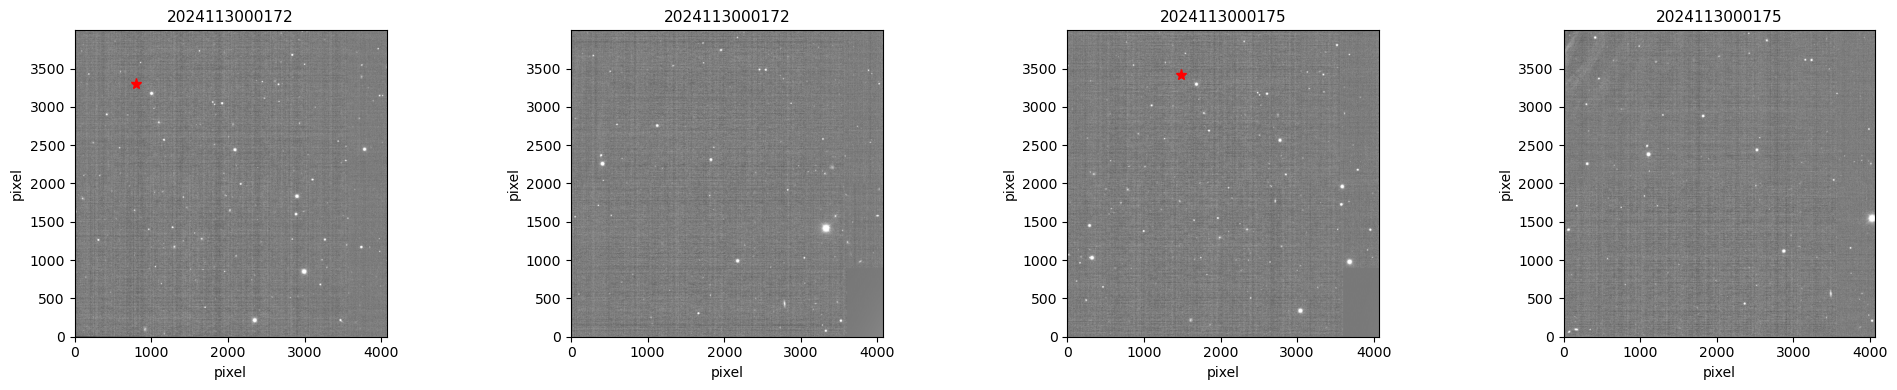

In [22]:
vr.plot_exposures_full(exposures_data[:,1],
                       center_coord=point_sky,
                       exposures_scale='percentile',
                       titles=list(map(str, exposures_data[:,0])),
                       axeslabels=['pixel', 'pixel'],
                       grid=False)

In [23]:
!butler query-datasets {LOCAL_REPO} directWarp

py.warnings WARNING: /opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/share/eups/Linux64/daf_butler/g6dd59efbe6+ec144cf465/python/lsst/daf/butler/cli/cmd/commands.py:490: FutureWarning: No --collections specified.  The --collections argument will become mandatory after v28.
  for table in script.QueryDatasets(**kwargs).getTables():


   type          run                        id                  instrument     skymap    tract patch     visit     band day_obs  physical_filter
---------- --------------- ------------------------------------ ---------- ------------- ----- ----- ------------- ---- -------- ---------------
directWarp direct_warp_run aa3edcb2-bfab-4d4d-9d15-933a1adf89c2 LSSTComCam lsst_cells_v1  5063    34 2024113000172    u 20241130            u_02
directWarp direct_warp_run 37c2f5f1-058d-4c94-889f-6cfff170eeee LSSTComCam lsst_cells_v1  5063    34 2024113000175    u 20241130            u_02
directWarp direct_warp_run e570e5ea-6f2b-4c4f-a1ca-8d439a22c017 LSSTComCam ls

In [35]:
# Load sky map
sky_map = lbutler_warp.get("skyMap", skymap="lsst_cells_v1")

tract_info = sky_map.findTract(point_sky)
patch_info = tract_info.findPatch(point_sky)

tract_id = tract_info.getId()
patch_index = patch_info.getSequentialIndex()

dat, labels = [], []
id_visit_test = 0000
for ref in visit_refs:
    dataId = {name: ref.dataId.get(name) for name in ref.dataId.dimensions.names}
    id_visit = dataId['visit']
    if id_visit == id_visit_test:
        continue
    id_visit_test = id_visit
    dataId['skymap'] = "lsst_cells_v1"
    dataId['tract'] = int(tract_id)
    dataId['patch'] = int(patch_index)
    dat.append(dataId)
    labels.append(dataId['visit'])

visit_warps = []
for warp_dataId in dat:
    visit_warps.append(lbutler_warp.get("directWarp", dataId=warp_dataId))

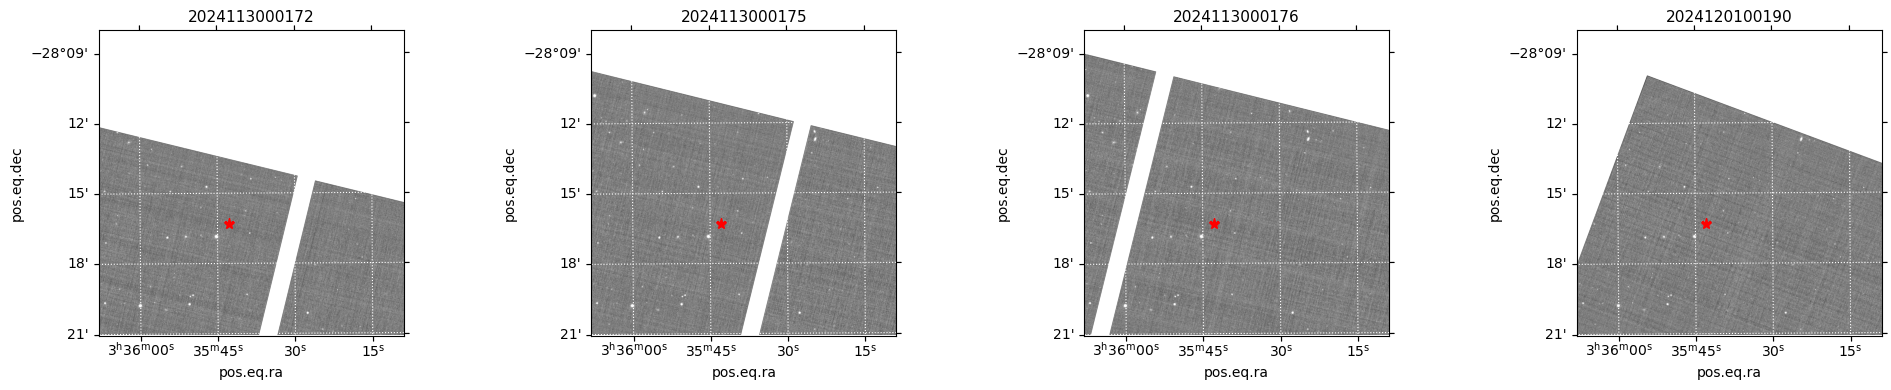

In [36]:
awcs = WCS(next(iter(visit_warps)).getWcs().getFitsMetadata().toDict())

vr.plot_exposures_full(visit_warps, # visit_warps.values(),
                       center_coord=point_sky,
                       exposures_scale='percentile',
                       titles=labels, #list(visit_warps.keys()),
                       #axeslabels=['pixel', 'pixel'],
                       projection=awcs,
                       grid=True,
                        )

## Making the Coadd

In [39]:
import pandas as pd

In [51]:
banda = ['u', 'u', 'u', 'u']

visits_selected = pd.DataFrame({
    'visit_id': labels,
    'band': banda
})

visits_selected

,visit_id,band
0,2024113000172,u
1,2024113000175,u
2,2024113000176,u
3,2024120100190,u


In [52]:
vr.custom_coadd_multiband(lbutler_warp, visits_selected, loc_data,
                           my_collection_identifier='custom_coadd',
                           repo_name='local_repo', bands=None, info=True, out=True,
                           sky_coordinates=True, skymap='lsst_cells_v1')

[INFO] Output collection: u/arestrada88/custom_coadd
[INFO] Query: tract = 5063 AND patch = 34 AND visit IN (2024113000172,2024113000175,2024113000176,2024120100190) AND skymap = 'lsst_cells_v1'
[INFO] Bands: ['u']


[INFO] Saved coadd metadata to: /home/arestrada88/local_repo/custom_coadd_info.txt


{'u': <lsst.afw.image._exposure.ExposureF at 0x782905d9d0b0>}

In [53]:
# The information of the custom coadd is in the file "custom_coadd_info.txt" inside of the repo
repo_name = "local_repo"
local_repo_path = os.path.join(os.getenv("HOME"), repo_name) 
info_txt_path = os.path.join(local_repo_path, "custom_coadd_info.txt")

coadd_results_butler = vr.load_custom_coadd_from_file(info_txt_path)

In [54]:
with open(info_txt_path, "r") as f:
    info = json.load(f)
info

{'repo_path': '/home/arestrada88/local_repo',
 'collection': 'u/arestrada88/custom_coadd/20260219T075314Z',
 'coadd_type': 'deep_coadd_predetection',
 'tract': 5063,
 'patch': '34',
 'bands': ['u'],
 'instrument': 'LSSTComCam',
 'skymap': 'lsst_cells_v1'}

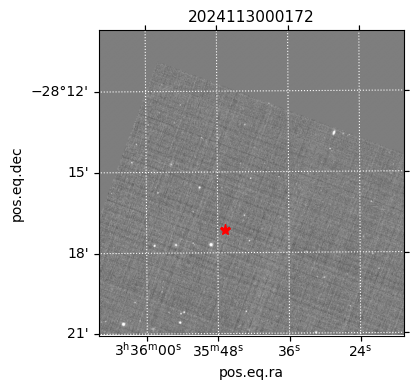

In [59]:
vr.plot_exposures_full([coadd_results_butler['u']], # visit_warps.values(),
                       center_coord=point_sky,
                       exposures_scale='percentile',
                       titles=labels, #list(visit_warps.keys()),
                       #axeslabels=['pixel', 'pixel'],
                       projection=awcs,
                       grid=True,
                        )